In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

The main objective of this project, 
The Goal is to predict a continuous price variable, 
1. Pricing decision
2. Market comparison
3. Investment analysis


In [5]:
# Load the dataset
data = pd.read_csv("../data/Housing.csv")

In [6]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Exploratory Data Analysis

In [8]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [11]:
# Train-Test Split
X = data.drop("price",axis=1)
y = data["price"]

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

Feature Engineering || Preprocessing 

In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer

In [19]:
numeric_features = X.select_dtypes(include=["int64"])
categorical_features = X.select_dtypes(include=["object"])

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(), numeric_features),
        ("cat",OneHotEncoder(drop="first"),categorical_features)
    ]
)

In [35]:
numeric_features = X.select_dtypes(include=["int64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Recreate preprocessor with correct column names
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(), numeric_features),
        ("cat",OneHotEncoder(drop="first"),categorical_features)
    ]
)

In [22]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                      area  bedrooms  bathrooms  stories  parking
0    7420         4          2        3        2
1    8960         4          4        4        3
2    9960         3          2        2        2
3    7500         4          2        2        3
4    7420         4          1        2        2
..    ...       ...        ...      ...      ...
540  3000         2          1        1        2
541  2400         3          1        1        0
542  3620         2          1        1        0
543  2910         3          1        1        0
544  3850         3          1        2        0

[545 rows x 5 columns]),
                                ('cat', OneHotEncoder(drop='first'),
                                     mainroad guestroom basement hotwaterheating airconditioning prefarea  \
0        yes        no       no              no             yes      yes   
1        yes        no       no              no             yes       no   
2        yes        no      yes              no              no      yes   
3        yes        no      yes              no             yes      yes   
4        yes       yes      yes              no             yes       no   
..       ...       ...      ...             ...             ...      ...   
540      yes        no      yes              no              no       no   
541       no        no       no              no              no       no   
542      yes        no       no              no              no       no   
543       no        no       no              no              no       no   
544      yes        no       no              no              no       no   

    furnishingstatus  
0          furnished  
1          furnished  
2     semi-furnished  
3          furnished  
4          furnished  
..               ...  
540      unfurnished  
541   semi-furnished  
542      unfurnished  
543        furnished  
544      unfurnished  

[545 rows x 7 columns])])

Baseline Model 


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [36]:
baseline_model =  Pipeline(steps= [
    ("preprocess",preprocessor),
    ("model",LinearRegression())
])
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('model', LinearRegression())])

Model Evaluation (Metrics)

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

In [38]:
y_pred = baseline_model.predict(X_test)

In [44]:
# Test Performace Metrics
# y_test = actuals values form test (unseed) data
# y_pred = predication made on X_test
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
print(" Test RMSE:",rmse)
print("Test R2 Score:",r2)

 Test RMSE: 1324506.96009144
Test R2 Score: 0.6529242642153177


In [43]:
# Train Performace Metrics
y_train_pred = baseline_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train,y_train_pred))
train_r2 = r2_score(y_train,y_train_pred)
print("Train Rmse:",train_rmse)
print("Train R2 Score:",train_r2)

Train Rmse: 984051.9236507412
Train R2 Score: 0.6859438988560158


Predict on Test Data

In [48]:
y_test_pred = baseline_model.predict(X_test)

Compare Actual vs Predicted (Table

In [49]:
test_result = pd.DataFrame({
    "Actual_Price":y_test,
    "Predicted_Price":y_test_pred,
    "Error":y_test-y_test_pred,
    "Absolute_Error":abs(y_test - y_test_pred)
})
test_result.head()

,Actual_Price,Predicted_Price,Error,Absolute_Error
316,4060000,5.164654e+06,-1.104654e+06,1.104654e+06
77,6650000,7.224722e+06,-5.747223e+05,5.747223e+05
360,3710000,3.109863e+06,6.001368e+05,6.001368e+05
90,6440000,4.612075e+06,1.827925e+06,1.827925e+06
493,2800000,3.294646e+06,-4.946463e+05,4.946463e+05


Percentage Error (Very Useful)

In [58]:
test_result['Percentage_Error'] = (
    test_result['Absolute_Error'] / test_result['Actual_Price']
) * 100


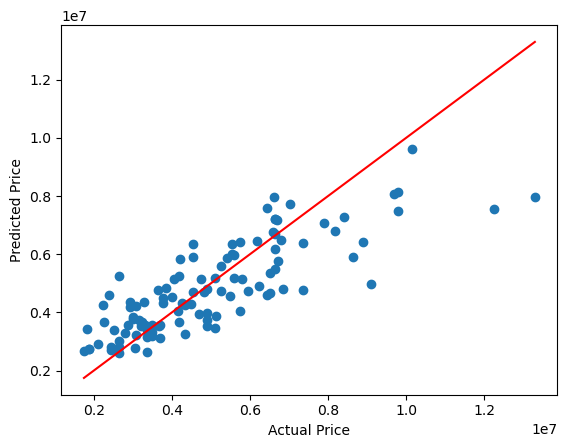

In [60]:
import matplotlib.pyplot as plt

plt.scatter(test_result['Actual_Price'], test_result['Predicted_Price'])
plt.plot(
    [test_result['Actual_Price'].min(), test_result['Actual_Price'].max()],
    [test_result['Actual_Price'].min(), test_result['Actual_Price'].max()],color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()


In [54]:
new_house = pd.DataFrame({
    'area': [7420],
    'bedrooms': [4],
    'bathrooms': [2],
    'stories': [3],
    'mainroad': ['no'],
    'guestroom': ['no'],
    'basement': ['no'],
    'hotwaterheating': ['no'],
    'airconditioning': ['yes'],
    'parking': [2],
    'prefarea': ['yes'],
    'furnishingstatus': ['furnished']
})

predicted_price = baseline_model.predict(new_house)
print("Predicted Price:", predicted_price[0])


Predicted Price: 7600356.178707803


In [55]:
13300000 - 7600356.17

5699643.83

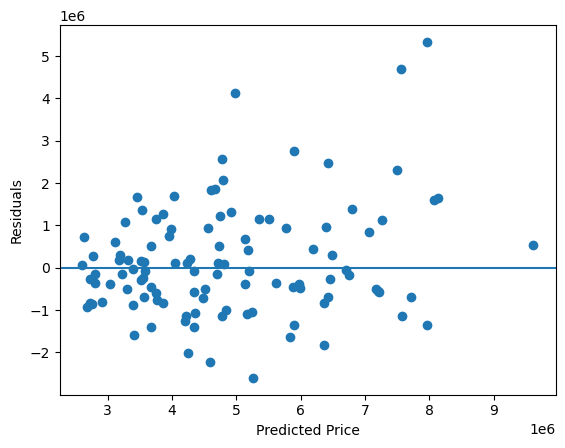

In [56]:
residuals = y_test - y_pred
plt.scatter(y_pred,residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()
